In [1]:
from transformers import AutoTokenizer

In [2]:
import logging

TOKENIZER_PATH = "/userspace/kpa/sr_xlstm/src/utils/tokenizer"
ZIP_FOLDER = "/storage0/kpa/datasets/speech/sova/RuYouTube"
ZIP_LIST = [
    "part_0.zip", "part_1.zip",
    "part_2.zip", "part_3.zip",
    "part_4.zip", "part_5.zip",
    "part_6.zip", "part_7.zip",
    "part_8.zip", "part_9.zip",
    "part_10.zip", "part_11.zip",
    "part_12.zip", "part_13.zip",
    "part_14.zip", "part_15.zip",
    "part_16.zip", "part_17.zip",
    "part_18.zip", "part_19.zip",
    "part_20.zip", "part_21.zip",
    "part_22.zip", "part_23.zip",
    "part_24.zip", "part_25.zip",
    "part_26.zip", "part_27.zip",
    "part_28.zip", "part_29.zip",
    "part_30.zip", "part_31.zip",
    "part_32.zip", "part_33.zip",
    "part_34.zip", "part_35.zip",
]
CUT_ZIP_LIST = ["part_23.zip", "part_24.zip", "part_25.zip"]

logger = logging.getLogger(__name__)
audio_len = []
tokens_len = []

In [3]:
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_PATH)

In [4]:
import io
from typing import List
import numpy as np
import soundfile as sf
import torch
import torchaudio

def get_duration_sec(wav_bytes: bytes) -> float:
    try:
        with io.BytesIO(wav_bytes) as buf:
            with sf.SoundFile(buf) as f:
                duration = len(f) / f.samplerate
        return duration
    except Exception as e:
        logger.warning(f"soundfile duration failed: {e}")
        return 0.0


def tokenize_text(text: str) -> List[int]:
    encoding = tokenizer(
        text,
        add_special_tokens=False,
        return_tensors=None
    )
    label_ids = np.array(encoding["input_ids"], dtype=np.int64)
    if tokenizer.pad_token_id is not None:
        label_ids[label_ids == tokenizer.pad_token_id] = -100
    return label_ids.tolist()


def check_audio(wav_bytes: bytes, path: str) -> tuple[str, str]:
    # try:
    #     with io.BytesIO(wav_bytes) as buf:
    #         waveform, sr = sf.read(buf, dtype="float32")
    # except Exception as e:
    #     return "error", str(e)
    
    try:
        with io.BytesIO(wav_bytes) as wav_io:
            waveform, sr = torchaudio.load_with_torchcodec(
                    wav_io, 
                    normalize=True
                )
    except Exception as e:
        return "error", str(e)

    max_abs = waveform.abs().max().item()
    if max_abs < 1e-6:
        print(f"file {path}, almost_silent: {max_abs:.4f}")

    rms = torch.sqrt(torch.mean(waveform ** 2)).item()
    if rms < 1e-4:
        print(f"file {path}, low_rms: {rms:.6f}")

    clip_ratio = (waveform.abs() >= 0.999).float().mean().item()
    if clip_ratio > 0.01:
        print(f"file {path}, too_much_clipping: {clip_ratio:.4f}")

    std = waveform.std().item()
    if std < 1e-8:
        print(f"file {path}, constant_signal: {std}")


In [5]:
import os
import zipfile


def fill_lenghts(zip_path, zip_name):
    current_file_idx = 0
    no_text_count = 0

    print(zip_name)
    zip_path = os.path.join(zip_path, zip_name)

    with zipfile.ZipFile(zip_path, 'r') as zf:
        file_list = sorted(zf.namelist())
        print(len(file_list))
        file_set = set(file_list)

        while current_file_idx < len(file_list):
            # Find wav file
            while current_file_idx < len(file_list) and not file_list[current_file_idx].endswith('.wav'):
                current_file_idx += 1
            
            if current_file_idx >= len(file_list):
                break
            
            # Find txt file by changing format
            wav_path = file_list[current_file_idx]
            txt_path = wav_path.replace('.wav', '.txt')
            
            if txt_path not in file_set:
                current_file_idx += 1
                continue
            
            try:
                # Processing wav file
                with zf.open(wav_path) as wav_file:
                    wav_bytes = wav_file.read()
                
                audio_len.append(get_duration_sec(wav_bytes))
                check_audio(wav_bytes, wav_path)

                # Processing text
                with zf.open(txt_path) as txt_file:
                    text = txt_file.read().decode('utf-8').strip()
                    if len(text) < 3:
                        no_text_count += 1

                tokens_len.append(len(tokenize_text(text)))
            
            except Exception as e:
                logger.warning(f"Processing error {wav_path}: {e}")
            
            # Continue to process list of files
            current_file_idx += 1
        
        if current_file_idx >= len(file_list):
            print(f"End of zip file, num files: {current_file_idx}")
            print(f"small/no text: {no_text_count}")

part_23.zip


334020


file raid/nanosemantics/nextcloud/sova_done/part_23/24a99fc9-c030-49d4-8bd7-0843ae562acb/000019.wav, too_much_clipping: 0.0417
file raid/nanosemantics/nextcloud/sova_done/part_23/24a99fc9-c030-49d4-8bd7-0843ae562acb/000021.wav, too_much_clipping: 0.0152
file raid/nanosemantics/nextcloud/sova_done/part_23/24a99fc9-c030-49d4-8bd7-0843ae562acb/000029.wav, too_much_clipping: 0.0522
file raid/nanosemantics/nextcloud/sova_done/part_23/24a99fc9-c030-49d4-8bd7-0843ae562acb/000033.wav, too_much_clipping: 0.0651


file raid/nanosemantics/nextcloud/sova_done/part_23/263dce1d-8a26-4ea3-885b-97d7e3762472/000005.wav, too_much_clipping: 0.0145
file raid/nanosemantics/nextcloud/sova_done/part_23/263dce1d-8a26-4ea3-885b-97d7e3762472/000010.wav, too_much_clipping: 0.0157
file raid/nanosemantics/nextcloud/sova_done/part_23/263dce1d-8a26-4ea3-885b-97d7e3762472/000011.wav, too_much_clipping: 0.0186


file raid/nanosemantics/nextcloud/sova_done/part_23/263dce1d-8a26-4ea3-885b-97d7e3762472/000012.wav, too_much_clipping: 0.0173


...

file raid/nanosemantics/nextcloud/sova_done/part_25/f3e153e9-83df-4a86-99e3-80bc1ef81302/000089.wav, too_much_clipping: 0.0167
file raid/nanosemantics/nextcloud/sova_done/part_25/f3e153e9-83df-4a86-99e3-80bc1ef81302/000093.wav, too_much_clipping: 0.0162


file raid/nanosemantics/nextcloud/sova_done/part_25/fa92b870-62c2-4aa4-ac38-fed04e22ba7a/000229.wav, too_much_clipping: 0.0103


file raid/nanosemantics/nextcloud/sova_done/part_25/fa92b870-62c2-4aa4-ac38-fed04e22ba7a/000601.wav, too_much_clipping: 0.0151
file raid/nanosemantics/nextcloud/sova_done/part_25/fa92b870-62c2-4aa4-ac38-fed04e22ba7a/000625.wav, too_much_clipping: 0.0225


file raid/nanosemantics/nextcloud/sova_done/part_25/fbbf8916-637d-46bc-bb5c-17838f09297a/000132.wav, too_much_clipping: 0.0145
file raid/nanosemantics/nextcloud/sova_done/part_25/fbbf8916-637d-46bc-bb5c-17838f09297a/000134.wav, too_much_clipping: 0.0100


End of zip file, num files: 334754
small/no text: 1470
501270
501270


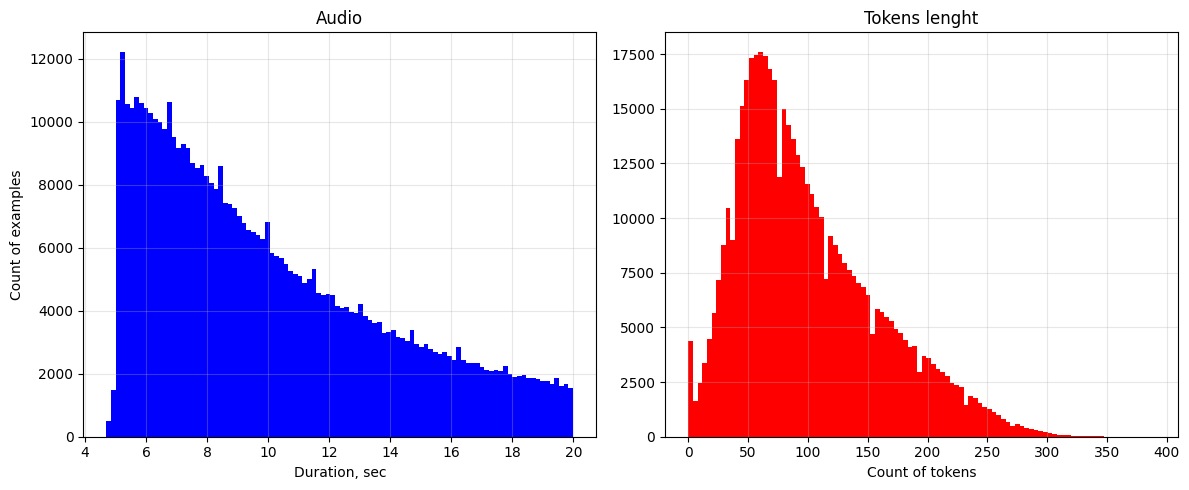

In [6]:
# Generate two normal distributions
from matplotlib import pyplot as plt

for file in CUT_ZIP_LIST:
    fill_lenghts(ZIP_FOLDER, file)
    print(len(audio_len))
    print(len(tokens_len))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=False, tight_layout=True)

ax1.hist(audio_len, bins=100, color='blue')
ax1.set_title("Audio")
ax1.set_xlabel("Duration, sec")
ax1.set_ylabel("Count of examples")
ax1.grid(True, alpha=0.3)

ax2.hist(tokens_len, bins=100, color='red')
ax2.set_title("Tokens lenght")
ax2.set_xlabel("Count of tokens")
ax2.grid(True, alpha=0.3)